In [2]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.feature import NaturalEarthFeature
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.cm import get_cmap
import metpy.calc as mpcalc
from metpy.units import units
from numpy import *
import xarray as xr
from netCDF4 import Dataset, num2date
import math
import pygrib
import cdsapi
from datetime import datetime, timedelta

In [3]:
def plot_maxmin_points(lon, lat, data, extrema, nsize, symbol, color='k',
                       plotValue=True, transform=None, ax=None):
    """
    This function will find and plot relative maximum and minimum for a 2D grid. The function
    can be used to plot an H for maximum values (e.g., High pressure) and an L for minimum
    values (e.g., low pressure). It is best to used filtered data to obtain  a synoptic scale
    max/min value. The symbol text can be set to a string value and optionally the color of the
    symbol and any plotted value can be set with the parameter color
    lon = plotting longitude values (2D)
    lat = plotting latitude values (2D)
    data = 2D data that you wish to plot the max/min symbol placement
    extrema = Either a value of max for Maximum Values or min for Minimum Values
    nsize = Size of the grid box to filter the max and min values to plot a reasonable number
    symbol = String to be placed at location of max/min value
    color = String matplotlib colorname to plot the symbol (and numerica value, if plotted)
    plot_value = Boolean (True/False) of whether to plot the numeric value of max/min point
    ax = axes object to plot onto, defaults to current axes
    The max/min symbol will be plotted only within the bounding frame
    (i.e., clip_on=True, clip_box=ax.bbox)
    """
    import matplotlib.pyplot as plt
    from scipy.ndimage.filters import maximum_filter, minimum_filter

    if ax is None:
        ax = plt.gca()
    
    if (extrema == 'max'):
        data_ext = maximum_filter(data, nsize, mode='nearest')
    elif (extrema == 'min'):
        data_ext = minimum_filter(data, nsize, mode='nearest')
    else:
        raise ValueError('Value for hilo must be either max or min')
        
    mxy, mxx = where(data_ext == data)
    
    for i in range(len(mxy)):
        ax.text(lon[mxy[i], mxx[i]], lat[mxy[i], mxx[i]], symbol, color=color, size=36,
                     clip_on=True, clip_box=ax.bbox, horizontalalignment='center', verticalalignment='center',
                     transform=transform)
        ax.text(lon[mxy[i], mxx[i]], lat[mxy[i], mxx[i]],
                     '\n' + str(int(data[mxy[i], mxx[i]])),
                     color=color, size=12, clip_on=True, clip_box=ax.bbox, fontweight='bold',
                     horizontalalignment='center', verticalalignment='top', transform=transform)

In [4]:
############# Declare time, level, and lat/lon boundaries here ##########
startdate = '02/01/26 00:00'    ## must be in this format 'MM/DD/YY HH:MM'
latN = 90
latS = 0
lonW = 180    # must be in degrees E (The western hemisphere is captured between -180 and 0 degrees east)
lonE = 330
date = datetime.strptime(startdate,'%m/%d/%y %H:%M')
level1 = 1000
level2 = 500
level3 = 250

In [ ]:
############### ONLY RUN THIS CELL ONCE TO ACQUIRE DATA #################
############### ONCE YOU HAVE RUN THIS CELL AND DOWNLOADED THE DATA YOU SHOULD COMMENT OUT ALL OF THE LINES BY PUTTING A # IN FRONT OF EVERY LINE #################
############### To see all of the possible data you can download from ERA5 go to the websites below. If you click "Show API Request" on the bottom of the page it will give you the info you can substitute in the request below for your own purposes 
############### Data on pressure levels: https://cds.climate.copernicus.eu/cdsapp#!/dataset/reanalysis-era5-pressure-levels?tab=form
############### Data on single levels: https://cds.climate.copernicus.eu/cdsapp#!/dataset/reanalysis-era5-single-levels?tab=form

filestr = 'synoptic_'+date.strftime('%Y')+date.strftime('%m')+date.strftime('%d')+'_'+date.strftime('%H')+'00.nc'     # you can change these filenames as you see fit
filestr2 = 'surface_'+date.strftime('%Y')+date.strftime('%m')+date.strftime('%d')+'_'+date.strftime('%H')+'00.nc'

######### Download ERA5 data using CDS-API ##########
client = cdsapi.Client()
dataset = "reanalysis-era5-pressure-levels"
request = {
    'product_type': ['reanalysis'],
    'variable': ['geopotential','u_component_of_wind','v_component_of_wind','vertical_velocity'],
    'year': [date.strftime('%Y')],
    'month': [date.strftime('%m')],
    'day': [date.strftime('%d')],
    'time': [date.strftime('%H:%M')],
    'pressure_level': [str(level1),str(level2),str(level3)],
    'data_format': 'netcdf',
    'download_format': 'unarchived',
    'area': [latN, lonW, latS, lonE]
}
client.retrieve(dataset, request, filestr)

dataset = "reanalysis-era5-single-levels"
request = {
    'product_type': ['reanalysis'],
    'variable': ['mean_sea_level_pressure','geopotential'],
    'year': [date.strftime('%Y')],
    'month': [date.strftime('%m')],
    'day': [date.strftime('%d')],
    'time': [date.strftime('%H:%M')],
    'data_format': 'netcdf',
    'download_format': 'unarchived',
    'area': [latN, lonW, latS, lonE]
}
client.retrieve(dataset, request, filestr2)

In [6]:
######## Enter in the datasets #########
filepmsl = '/gdex/data/d633000/e5.oper.an.sfc/202602/e5.oper.an.sfc.128_151_msl.ll025sc.2026020100_2026022823.nc'
filez = '/gdex/data/d633000/e5.oper.an.pl/202602/e5.oper.an.pl.128_129_z.ll025sc.2026020100_2026020123.nc'
fileuwnd = '/gdex/data/d633000/e5.oper.an.pl/202602/e5.oper.an.pl.128_131_u.ll025uv.2026020100_2026020123.nc'
filevwnd = '/gdex/data/d633000/e5.oper.an.pl/202602/e5.oper.an.pl.128_132_v.ll025uv.2026020100_2026020123.nc'

dpmsl = xr.open_dataset(filepmsl).metpy.parse_cf()
print(list(dpmsl.data_vars))

dz = xr.open_dataset(filez).metpy.parse_cf()
duwnd = xr.open_dataset(fileuwnd).metpy.parse_cf()
dvwnd = xr.open_dataset(filevwnd).metpy.parse_cf()

#date = dtcwv.time.values[4]

######## Read in the variables ##########
pmsl = dpmsl.MSL.metpy.sel(time=date,latitude=slice(latN,latS),longitude=slice(lonW,lonE))
pmsl_hilo = dpmsl.MSL.metpy.sel(time=date,latitude=slice(latN,latS),longitude=slice(lonW,lonE))
elev = dz.Z.metpy.sel(time=date,latitude=slice(latN,latS),longitude=slice(lonW,lonE))
lats = dpmsl.latitude.metpy.sel(latitude=slice(latN,latS))
lons = dpmsl.longitude.metpy.sel(longitude=slice(lonW,lonE))
lons_2D, lats_2D = meshgrid(lons,lats)

geop1 = dz.Z.metpy.sel(time=date,level=level1,latitude=slice(latN,latS),longitude=slice(lonW,lonE))
geop2 = dz.Z.metpy.sel(time=date,level=level2,latitude=slice(latN,latS),longitude=slice(lonW,lonE))
uwnd = duwnd.U.metpy.sel(time=date,level=level3,latitude=slice(latN,latS),longitude=slice(lonW,lonE))
vwnd = dvwnd.V.metpy.sel(time=date,level=level3,latitude=slice(latN,latS),longitude=slice(lonW,lonE))
dx, dy = mpcalc.lat_lon_grid_deltas(lons, lats)

hght1 = geop1/9.81    # need to divide the geopotential by gravity to get the geopotential height
hght2 = geop2/9.81
elev = elev/9.81
corl = 2.0*7.292e-5*sin(lats*(pi/180.)) / units.second     # Coriolis Parameter

['MSL', 'quantization_info', 'utc_date']


In [7]:
######### Smooth the variables ##########
hght1 = mpcalc.smooth_gaussian(hght1,25)
hght2 = mpcalc.smooth_gaussian(hght2,25)
pmsl = mpcalc.smooth_gaussian(pmsl,25)
uwnd = mpcalc.smooth_gaussian(uwnd,25)
vwnd = mpcalc.smooth_gaussian(vwnd,25)

In [8]:
########### Calculate additional variables to plot #########
thck = hght2 - hght1     # thickness
wspd = mpcalc.wind_speed(uwnd,vwnd)   # wind speed
wspd = mpcalc.smooth_gaussian(wspd,5)

########## Scale the pressure so it plots correctly #########
scale = -2     # units of pmsl are Pa , this turns it to hPa

/glade/derecho/scratch/zposner/tmp/ipykernel_65973/3823524132.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  wspd_fcontours = plt.contourf(lons_2D, lats_2D, wspd, levels=wspd_levels, cmap=get_cmap('BuPu'), alpha=1, transform=ccrs.PlateCarree(),transform_first=True)
/glade/derecho/scratch/zposner/tmp/ipykernel_65973/3309769152.py:22: DeprecationWarning: Please import `maximum_filter` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.filters import maximum_filter, minimum_filter
/glade/derecho/scratch/zposner/tmp/ipykernel_65973/3309769152.py:22: DeprecationWarning: Please import `minimum_filter` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.

Text(1.0, 1.0, 'Valid:02/01/26 00:00')

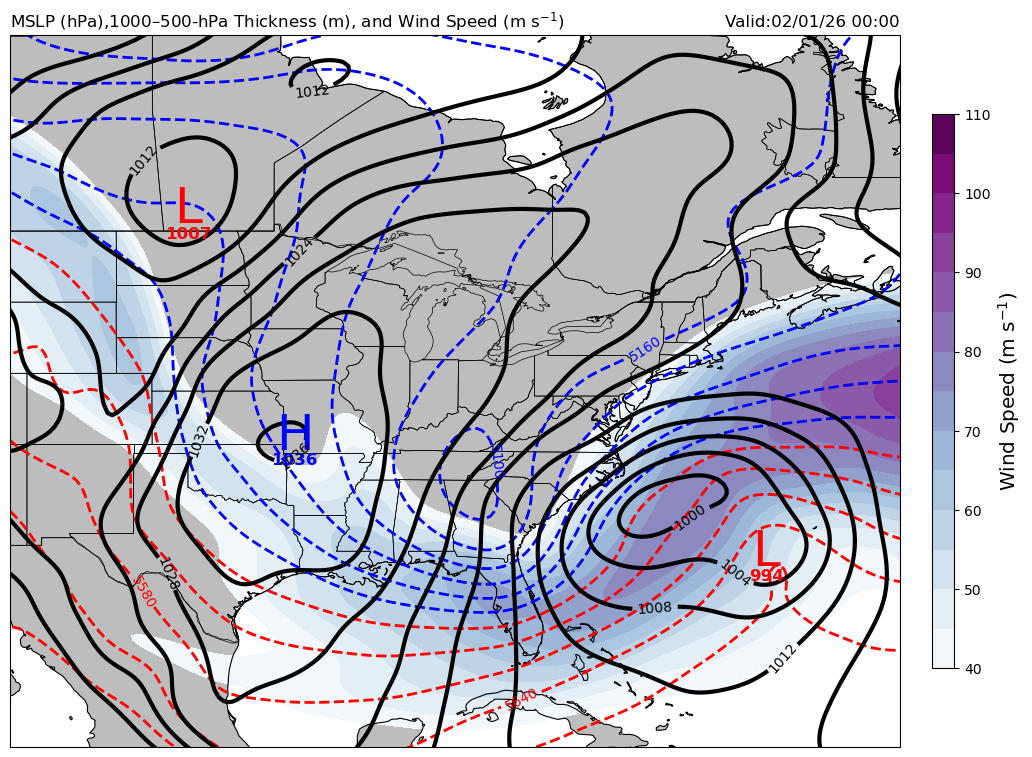

In [10]:
######## Create the plot #######

#Set up the projection that will be used
mapcrs = ccrs.LambertConformal(central_longitude=-55, central_latitude=45, standard_parallels=(33, 45)) 
mapcrs = ccrs.PlateCarree()

#Set up the projection of the data; if lat/lon then PlateCarree is what you want
datacrs = ccrs.PlateCarree()

#Start the figure and create plot axes with proper projection
fig = plt.figure(1, figsize=(14, 12)) 
ax = plt.subplot(111, projection=mapcrs) 
ax.set_extent([-110, -60, 20, 60], ccrs.PlateCarree()) ## Can change the lat/lon bounds

#Add geopolitical boundaries for map reference
ax.add_feature(cfeature.LAND, facecolor="#bdbdbd") 
countries = NaturalEarthFeature(category="cultural", scale="110m", facecolor="none", name="admin_0_boundary_lines_land") 
ax.add_feature(countries, linewidth=0.5, edgecolor="black") 
ax.add_feature(cfeature.STATES.with_scale('50m'), linewidth=0.5) 
ax.coastlines('50m', linewidth=0.8)

#Set up contour and fill intervals
thck1_levels = arange(4020,5460,60) 
thck2_levels = arange(5460,7020,60) 
pmsl_levels = arange(940,1080,4) 
wspd_levels = arange(40,115,5)

#Plot the variables
wspd_fcontours = plt.contourf(lons_2D, lats_2D, wspd, levels=wspd_levels, cmap=get_cmap('BuPu'), alpha=1, transform=ccrs.PlateCarree(),transform_first=True)
thck1_contours = plt.contour(lons_2D, lats_2D, thck, levels=thck1_levels, colors="blue", linestyles='dashed',linewidths=2.0, transform=ccrs.PlateCarree(),transform_first=True) 
thck2_contours = plt.contour(lons_2D, lats_2D, thck, levels=thck2_levels, colors="red", linestyles='dashed',linewidths=2.0, transform=ccrs.PlateCarree(),transform_first=True) 
pmsl_contours = plt.contour(lons_2D, lats_2D, pmsl*10**scale, levels=pmsl_levels, colors="black", linewidths=3.0, transform=ccrs.PlateCarree(),transform_first=True)

plot_maxmin_points(lons_2D, lats_2D, pmsl_hilo*10**scale, 'max', 100, symbol='H', color='b', transform=datacrs) 
plot_maxmin_points(lons_2D, lats_2D, pmsl_hilo*10**scale, 'min', 100, symbol='L', color='r', transform=datacrs)

#Colorbar and contour labels
cb = fig.colorbar(wspd_fcontours, orientation='vertical', pad=0.03, extendrect=True, aspect=25, shrink=0.6)
cb.set_label('Wind Speed (m s$^{-1}$)', size='x-large') 
plt.clabel(thck1_contours, fmt='%d') 
plt.clabel(thck2_contours, fmt='%d') 
plt.clabel(pmsl_contours, fmt='%d')

#Plot two titles, one on right and left side
plt.title('MSLP (hPa),1000–500-hPa Thickness (m), and Wind Speed (m s$^{-1}$)', loc='left') 
plt.title('Valid:'+startdate, loc='right')

#Save figure
#fig.savefig('[insert_name].pdf')

In [ ]:
######## Create the plot #######

#Set up the projection that will be used
mapcrs = ccrs.LambertConformal(central_longitude=-55, central_latitude=45, standard_parallels=(33, 45)) 
mapcrs = ccrs.PlateCarree()

#Set up the projection of the data; if lat/lon then PlateCarree is what you want
datacrs = ccrs.PlateCarree()

#Start the figure and create plot axes with proper projection
fig = plt.figure(1, figsize=(14, 12)) 
ax = plt.subplot(111, projection=mapcrs) 
ax.set_extent([67, 107, 25, 42], ccrs.PlateCarree()) ## Can change the lat/lon bounds

#Add geopolitical boundaries for map reference
ax.add_feature(cfeature.LAND, facecolor="#bdbdbd") 
countries = NaturalEarthFeature(category="cultural", scale="110m", facecolor="none", name="admin_0_boundary_lines_land") 
ax.add_feature(countries, linewidth=0.5, edgecolor="black") 
ax.add_feature(cfeature.STATES.with_scale('50m'), linewidth=0.5) 
ax.coastlines('50m', linewidth=0.8)

#Set up contour and fill intervals
elev_levels = arange(0,5000,60) 

#Plot the variables
elev_fcontours = plt.contourf(lons_2D, lats_2D, elev, levels=elev_levels, cmap=get_cmap('terrain'), alpha=1, transform=ccrs.PlateCarree(),transform_first=True)

#Colorbar and contour labels
cb = fig.colorbar(elev_fcontours, orientation='vertical', pad=0.03, extendrect=True, aspect=25, shrink=0.6)
cb.set_label('Elevation (m)', size='x-large') 

#Plot two titles, one on right and left side
#plt.title('MSLP (hPa),1000–500-hPa Thickness (m), and Wind Speed (m s$^{-1}$)', loc='left') 
#plt.title('Valid:'+startdate, loc='right')

#Save figure
#fig.savefig('[insert_name].pdf')